In [25]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense,SimpleRNN,TimeDistributed
from tensorflow.keras.optimizers import Adam

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 9, 1)           │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 9, 1)           │             2 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - loss: 0.1163
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1161
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1160
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1159
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1159
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1158
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1158
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1158
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1157
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1157
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1156
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1155
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1155
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1154
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.1153
Epo

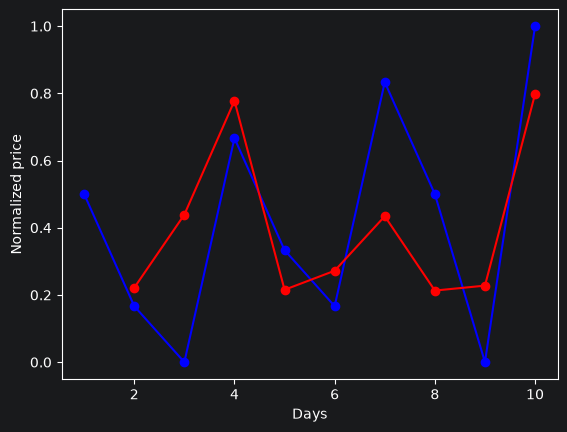

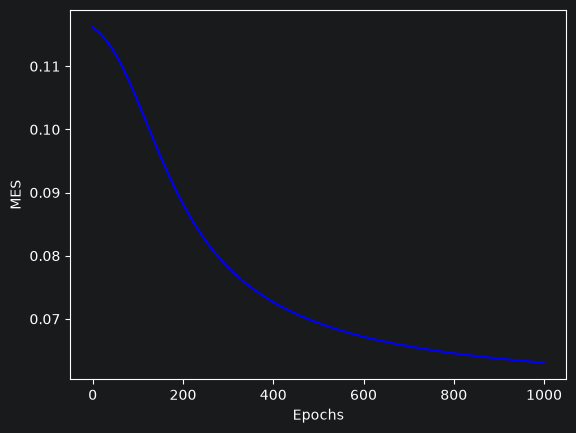

In [38]:
y = np.array([9, 7, 6, 10, 8, 7, 11, 9, 6, 12])
yn = (y - np.min(y)) / (np.max(y) - np.min(y))

X = yn [:-1] # Remove the last value
Y = yn [1:] # Remove the first value

XM=X.reshape(1,9,1)
YM=Y.reshape(1,9,1)

random.seed(3)

model = Sequential([
    Input(shape=(9, 1)),
    SimpleRNN(
        1,
        return_sequences=True,
        activation="sigmoid"
    ),
    TimeDistributed(
        Dense(1, activation="sigmoid")
    )
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    loss="mean_squared_error",
    optimizer=optimizer
)

model.summary()

history = model.fit(XM, YM, epochs=1000 , verbose="auto", batch_size=3)

Yp = model.predict(XM, verbose=0)

Yp = Yp.flatten()
t = np.arange(1, len(yn)+1)
t2 = np.arange(2, len(yn)+1)
plt.plot(t,yn, linestyle="-", marker="o", color="blue")
plt.plot(t2, Yp, linestyle="-", marker="o", color="red")
plt.xlabel("Days")
plt.ylabel("Normalized price")
plt.show()

model.get_weights()

# Plot the training loss over epochs
plt.plot(history.history["loss"], linestyle="-", color="blue")
plt.xlabel("Epochs")
plt.ylabel("MES")
plt.show()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - loss: 0.3234
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3189
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.3146
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.3102
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.3059
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.3017
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2974
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.2933
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2892
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2851
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2811
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2771
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2732
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.2693
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2655
Epo

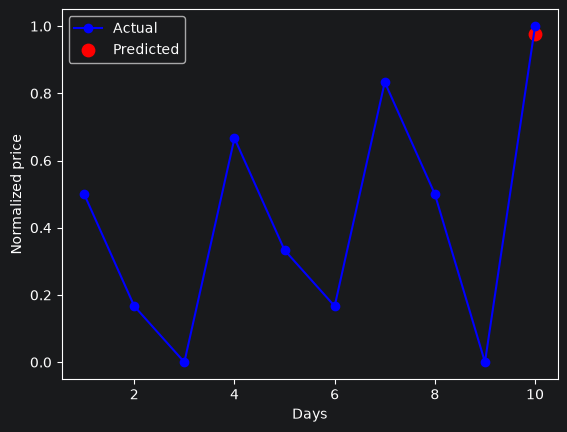

Actual Day 10 : 1.0
Predicted Day 10: [0.97526294]


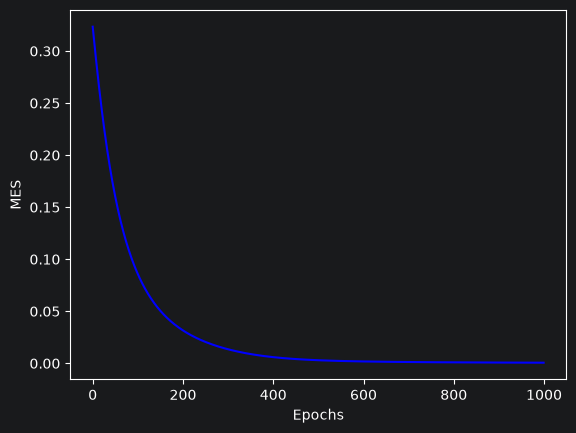

In [42]:
##VERSION-2

y = np.array([9, 7, 6, 10, 8, 7, 11, 9, 6, 12])
yn = (y - np.min(y)) / (np.max(y) - np.min(y))

X = yn[:-1]  # Remove the last value
Y = yn[9]  # Exact Last Value

XM = X.reshape(1, 9, 1)
YM = Y.reshape(1, 1, 1)

random.seed(3)

model = Sequential([
    Input(shape=(9, 1)),
    SimpleRNN(
        1,
        activation="sigmoid"
    ),
    Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    loss="mean_squared_error",
    optimizer=optimizer
)

model.summary()

history = model.fit(XM, YM, epochs=1000, verbose="auto", batch_size=3)

Yp = model.predict(XM, verbose=0)

plt.plot(
    np.arange(1, len(yn) + 1),
    yn,
    linestyle="-",
    marker="o",
    color="blue",
    label="Actual"
)

plt.scatter(
    10,
    Yp[0],
    color="red",
    s=80,
    label="Predicted"
)

plt.xlabel("Days")
plt.ylabel("Normalized price")
plt.legend()
plt.show()

print("Actual Day 10 :", yn[9])
print("Predicted Day 10:", Yp[0])

model.get_weights()

# Plot the training loss over epochs
plt.plot(history.history["loss"], linestyle="-", color="blue")
plt.xlabel("Epochs")
plt.ylabel("MES")
plt.show()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.1480
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1475
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1466
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1462
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1457
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1454
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1460
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1449
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1447
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1444
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1445
Epoch 12/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1444
Epoch 13/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1439
Epoch 14/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1438
Epoch 15/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1437
Epoc

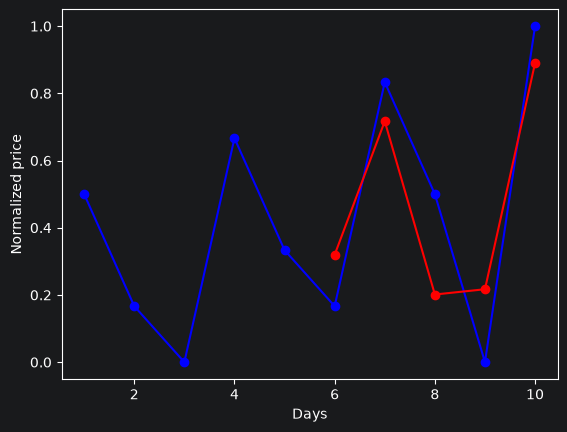

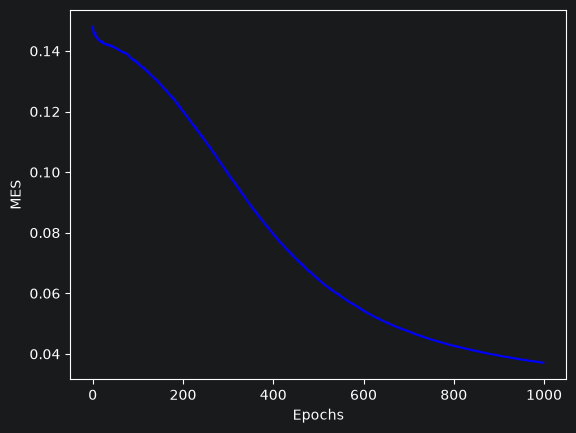

In [41]:
##VERSION-3

y = np.array([9, 7, 6, 10, 8, 7, 11, 9, 6, 12])
yn = (y - np.min(y)) / (np.max(y) - np.min(y))

X = []
Y = []

step = 5
for i in range(step, len (yn)):
    X.append (yn[i-step:i])
    Y.append(yn [i])

XM = np.reshape(X, (5,5,1)) # Data, samples, time steps, features
YM = np.reshape(Y,(5,1,1))

random.seed(3)

model = Sequential([
    Input(shape=(5, 1)),
    SimpleRNN(
        1,
        activation="sigmoid"
    ),
    Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    loss="mean_squared_error",
    optimizer=optimizer
)

model.summary()

history = model.fit(XM, YM, epochs=1000, verbose="auto", batch_size=3)

Yp = model.predict(XM, verbose=0)

Yp = Yp.flatten()
t = np.arange(1, len(yn) + 1)
t2 = np.arange (step+1, len(yn)+1)
plt.plot(t, yn, linestyle="-", marker="o", color="blue")
plt.plot(t2, Yp, linestyle="-", marker="o", color="red")
plt.xlabel("Days")
plt.ylabel("Normalized price")
plt.show()

model.get_weights()

# Plot the training loss over epochs
plt.plot(history.history["loss"], linestyle="-", color="blue")
plt.xlabel("Epochs")
plt.ylabel("MES")
plt.show()